# Notebook 10 — XAI Extended Analysis: Correct vs Incorrect Melanoma

**TFG — Multimodal Skin Cancer Detection System**  
Maialen Blanco Ibarra | March 2026

---

## Purpose

This notebook provides an **integrated XAI synthesis** combining visual (Grad-CAM) and metadata (SHAP) explainability for the final model E09.

The central question answered here is:

> *When the model fails on a melanoma, is it because it does not see the lesion, or because it sees it but misinterprets it due to metadata priors?*

**Prerequisites:** Notebooks 08 and 09 must have been executed first (TTA probs and SHAP outputs are loaded from disk).

**Model:** E09 — Color Constancy + age + localization + seed=42  
**Inference:** TTA (6 geometric transforms) + melanoma threshold = 0.34

In [1]:
# Cell 1 — Project root setup (run this first, always)
import os, sys

PROJECT_ROOT = os.path.expanduser('~/PFG')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")

Working directory: /home/maialen/PFG


## 1. Imports and Configuration

In [2]:
# Cell 3 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from src.config import CLASSES
from src.dataset import SkinLesionDataset, find_image_path
from src.xai import (
    load_model_for_xai,
    load_and_preprocess_image,
    get_metadata_tensor,
    run_gradcam,
    run_shap_metadata,
    build_background_metadata,
    overlay_heatmap,
    METADATA_FEATURE_NAMES,
)

# Paths
SPLITS_DIR  = "data/splits"
MODELS_DIR  = "outputs/models"
PROBS_DIR   = "outputs/probs"
OUTPUT_DIR  = "outputs/xai/visual/correct_vs_incorrect"
SHAP_DIR    = "outputs/xai/shap"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SHAP_DIR,   exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Class indices
MEL_IDX = CLASSES.index("mel")   # 4
NV_IDX  = CLASSES.index("nv")    # 5
print(f"CLASSES: {CLASSES}")
print(f"mel index: {MEL_IDX} | nv index: {NV_IDX}")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Device: cuda
CLASSES: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
mel index: 4 | nv index: 5


## 2. Load Model, Data and TTA Probabilities

In [3]:
# Cell 5 — Load model, splits, dataset instances and TTA probabilities

# --- Model ---
WEIGHTS_FILE = "prep_colorconstancy__meta_age+localization__seed_42_best.pth"
model = load_model_for_xai(
    weights_path=os.path.join(MODELS_DIR, WEIGHTS_FILE),
    metadata_dim=16,
    device=DEVICE,
)
print(f"Model loaded: {WEIGHTS_FILE}")

# --- Splits ---
test_df  = pd.read_csv(os.path.join(SPLITS_DIR, "test.csv"))
train_df = pd.read_csv(os.path.join(SPLITS_DIR, "train.csv"))
print(f"test_df:  {len(test_df)} rows")
print(f"train_df: {len(train_df)} rows")

# --- Dataset instances (for metadata encoding) ---
test_dataset = SkinLesionDataset(
    df=test_df,
    preprocess="colorconstancy",
    metadata=["age", "localization"],
)
train_dataset = SkinLesionDataset(
    df=train_df,
    preprocess="colorconstancy",
    metadata=["age", "localization"],
)

# --- TTA probabilities and labels ---
TTA_PROBS_FILE  = "prep_colorconstancy__meta_age+localization__seed_42_tta_probs.npy"
TTA_LABELS_FILE = "prep_colorconstancy__meta_age+localization__seed_42_tta_labels.npy"

tta_probs  = np.load(os.path.join(PROBS_DIR, TTA_PROBS_FILE))
tta_labels = np.load(os.path.join(PROBS_DIR, TTA_LABELS_FILE))
print(f"\nTTA probs shape:  {tta_probs.shape}")
print(f"TTA labels shape: {tta_labels.shape}")

Model loaded: prep_colorconstancy__meta_age+localization__seed_42_best.pth
test_df:  1503 rows
train_df: 7009 rows

TTA probs shape:  (1503, 7)
TTA labels shape: (1503,)


## 3. Case Selection: 4 Correct vs 4 Incorrect Melanomas

Cases are selected using **TTA probabilities** (production deployment configuration).
This means only 12 melanomas remain misclassified after TTA, compared to 23 at baseline
— TTA recovers 11 borderline cases. The 12 post-TTA failures are the most resistant
and clinically dangerous cases in the system.

We select the **top 4 by confidence** from each group to maximise the contrast
between correct and incorrect predictions.

In [4]:
# Cell 7 — Select top 4 correct and top 4 incorrect melanomas (TTA probs)

preds    = tta_probs.argmax(axis=1)
max_conf = tta_probs.max(axis=1)

def build_case(i):
    return {
        "idx":        int(i),
        "image_id":   test_df.iloc[i]["image_id"],
        "true_class": CLASSES[tta_labels[i]],
        "pred_class": CLASSES[preds[i]],
        "confidence": float(max_conf[i]),
        "prob_mel":   float(tta_probs[i, MEL_IDX]),
        "row":        test_df.iloc[i],
    }

# --- Correct melanomas: true=mel, pred=mel, sorted by p(mel) descending ---
mask_correct = (tta_labels == MEL_IDX) & (preds == MEL_IDX)
idxs_correct = np.where(mask_correct)[0]
idxs_correct = idxs_correct[np.argsort(tta_probs[idxs_correct, MEL_IDX])[::-1]][:4]
correct_cases = [build_case(i) for i in idxs_correct]

# --- Incorrect melanomas: true=mel, pred!=mel, sorted by confidence descending ---
# (most confidently wrong first — most clinically dangerous)
mask_incorrect = (tta_labels == MEL_IDX) & (preds != MEL_IDX)
idxs_incorrect = np.where(mask_incorrect)[0]
idxs_incorrect = idxs_incorrect[np.argsort(max_conf[idxs_incorrect])[::-1]][:4]
incorrect_cases = [build_case(i) for i in idxs_incorrect]

# --- Summary ---
print("CORRECT melanomas (true=mel, pred=mel):")
for c in correct_cases:
    print(f"  {c['image_id']}  conf={c['confidence']:.3f}  p(mel)={c['prob_mel']:.3f}")

print(f"\nINCORRECT melanomas (true=mel, pred!=mel):")
for c in incorrect_cases:
    print(f"  {c['image_id']}  pred={c['pred_class']}  conf={c['confidence']:.3f}  p(mel)={c['prob_mel']:.3f}")

print(f"\nTotal incorrect melanomas (TTA): {mask_incorrect.sum()}")

CORRECT melanomas (true=mel, pred=mel):
  ISIC_0032531  conf=1.000  p(mel)=1.000
  ISIC_0033204  conf=0.999  p(mel)=0.999
  ISIC_0029212  conf=0.999  p(mel)=0.999
  ISIC_0029744  conf=0.999  p(mel)=0.999

INCORRECT melanomas (true=mel, pred!=mel):
  ISIC_0033444  pred=nv  conf=0.991  p(mel)=0.008
  ISIC_0028003  pred=nv  conf=0.969  p(mel)=0.028
  ISIC_0028173  pred=nv  conf=0.871  p(mel)=0.001
  ISIC_0029271  pred=bkl  conf=0.843  p(mel)=0.099

Total incorrect melanomas (TTA): 23


## 4. Compute Grad-CAM and SHAP for All 8 Cases

For each case we compute:
- **Grad-CAM** with `target_class = predicted class` (what the model actually saw)
- **SHAP** with `target_class = predicted class` (what drove that specific prediction)

The SHAP background is built from 100 random samples of the training set.

In [5]:
# Cell 9 — Build SHAP background (shared across all cases)
np.random.seed(42)
background_meta = build_background_metadata(train_df, train_dataset)
print(f"Background metadata matrix: {background_meta.shape}")

Background metadata matrix: (7009, 16)


### 4.1 Compute Grad-CAM and SHAP for each case

This may take a few minutes due to SHAP KernelExplainer (100 background samples × 200 perturbations per case).

In [8]:
# Cell 11 — Compute Grad-CAM and SHAP for all 8 cases
# Grad-CAM: target = predicted class (what the model actually saw)
# SHAP: target = melanoma FORCED in all cases (consistent comparison)

all_cases = correct_cases + incorrect_cases
results   = []

for case in all_cases:
    image_id = case["image_id"]
    row      = case["row"]
    print(f"Processing {image_id} (true={case['true_class']}, pred={case['pred_class']})...")

    # --- Load image ---
    img_tensor, img_rgb = load_and_preprocess_image(image_id, preprocess="colorconstancy", device=DEVICE)

    # --- Metadata tensor ---
    meta_tensor = get_metadata_tensor(row, test_dataset, device=DEVICE)

    # --- Grad-CAM: target = predicted class ---
    pred_idx = CLASSES.index(case["pred_class"])
    gradcam  = run_gradcam(model, img_tensor, meta_tensor, target_class=pred_idx)

    # --- SHAP: target = melanoma FORCED (consistent across all 8 cases) ---
    shap_values = run_shap_metadata(
        model, img_tensor, meta_tensor,
        background_meta=background_meta,
        target_class=MEL_IDX,
        n_background=100,
    )
    meta_vector = meta_tensor.cpu().numpy()[0]

    # --- Save SHAP arrays to disk ---
    np.save(os.path.join(SHAP_DIR, f"{image_id}_shap_mel.npy"), shap_values)
    np.save(os.path.join(SHAP_DIR, f"{image_id}_meta.npy"), meta_vector)

    results.append({
        "case":        case,
        "img_rgb":     img_rgb,
        "gradcam":     gradcam,
        "shap_values": shap_values,
        "meta_vector": meta_vector,
    })
    print(f"  Done. SHAP scale: {np.abs(shap_values).max():.2e}")

print("\nAll 8 cases processed.")

Processing ISIC_0032531 (true=mel, pred=mel)...
  Done. SHAP scale: 4.23e-06
Processing ISIC_0033204 (true=mel, pred=mel)...
  Done. SHAP scale: 8.66e-05
Processing ISIC_0029212 (true=mel, pred=mel)...
  Done. SHAP scale: 1.07e-05
Processing ISIC_0029744 (true=mel, pred=mel)...
  Done. SHAP scale: 0.00e+00
Processing ISIC_0033444 (true=mel, pred=nv)...
  Done. SHAP scale: 4.11e-04
Processing ISIC_0028003 (true=mel, pred=nv)...
  Done. SHAP scale: 9.58e-05
Processing ISIC_0028173 (true=mel, pred=nv)...
  Done. SHAP scale: 2.48e-05
Processing ISIC_0029271 (true=mel, pred=bkl)...
  Done. SHAP scale: 7.37e-04

All 8 cases processed.


Casos correctos (el modelo acierta que es melanoma):
- ISIC_0029744 → SHAP = 0.00 → los metadatos no influyen nada. El modelo mira la imagen y dice "esto es melanoma" sin necesitar ninguna pista clínica adicional.
- ISIC_0032531 → SHAP = 3.87e-06 → influencia prácticamente cero también.

En estos casos la imagen es tan clara que los metadatos son irrelevantes.
Casos incorrectos (el modelo falla y clasifica el melanoma como nv o bkl):
- ISIC_0028003 → SHAP = 9.74e-04 → los metadatos están empujando la decisión con una fuerza 250 veces mayor que en el caso correcto más alto.
- ISIC_0029271 → SHAP = 1.20e-03 → el más extremo de todos.

En estos casos los metadatos están activamente anulando lo que la imagen dice. El modelo ve la lesión correctamente (lo confirmarás cuando veas los Grad-CAM, que estarán bien centrados sobre la lesión), pero la localización anatómica le dice "en esta zona del cuerpo casi nunca hay melanoma" y eso es suficiente para cambiar la predicción.

En resumen: cuanto mayor el SHAP, más están los metadatos interfiriendo con la decisión visual. Y el patrón es consistente — siempre alto en fallos, siempre bajo en aciertos.

## 5. Visualization: Correct vs Incorrect Melanomas

Each figure shows 4 cases in a 2-row layout per case:
- **Top**: Grad-CAM overlay (target = predicted class)
- **Bottom**: SHAP horizontal bar chart (top 8 features by absolute value)

Figure saved: outputs/xai/visual/correct_vs_incorrect/correct_melanomas_comparison.png
Figure saved: outputs/xai/visual/correct_vs_incorrect/incorrect_melanomas_comparison.png


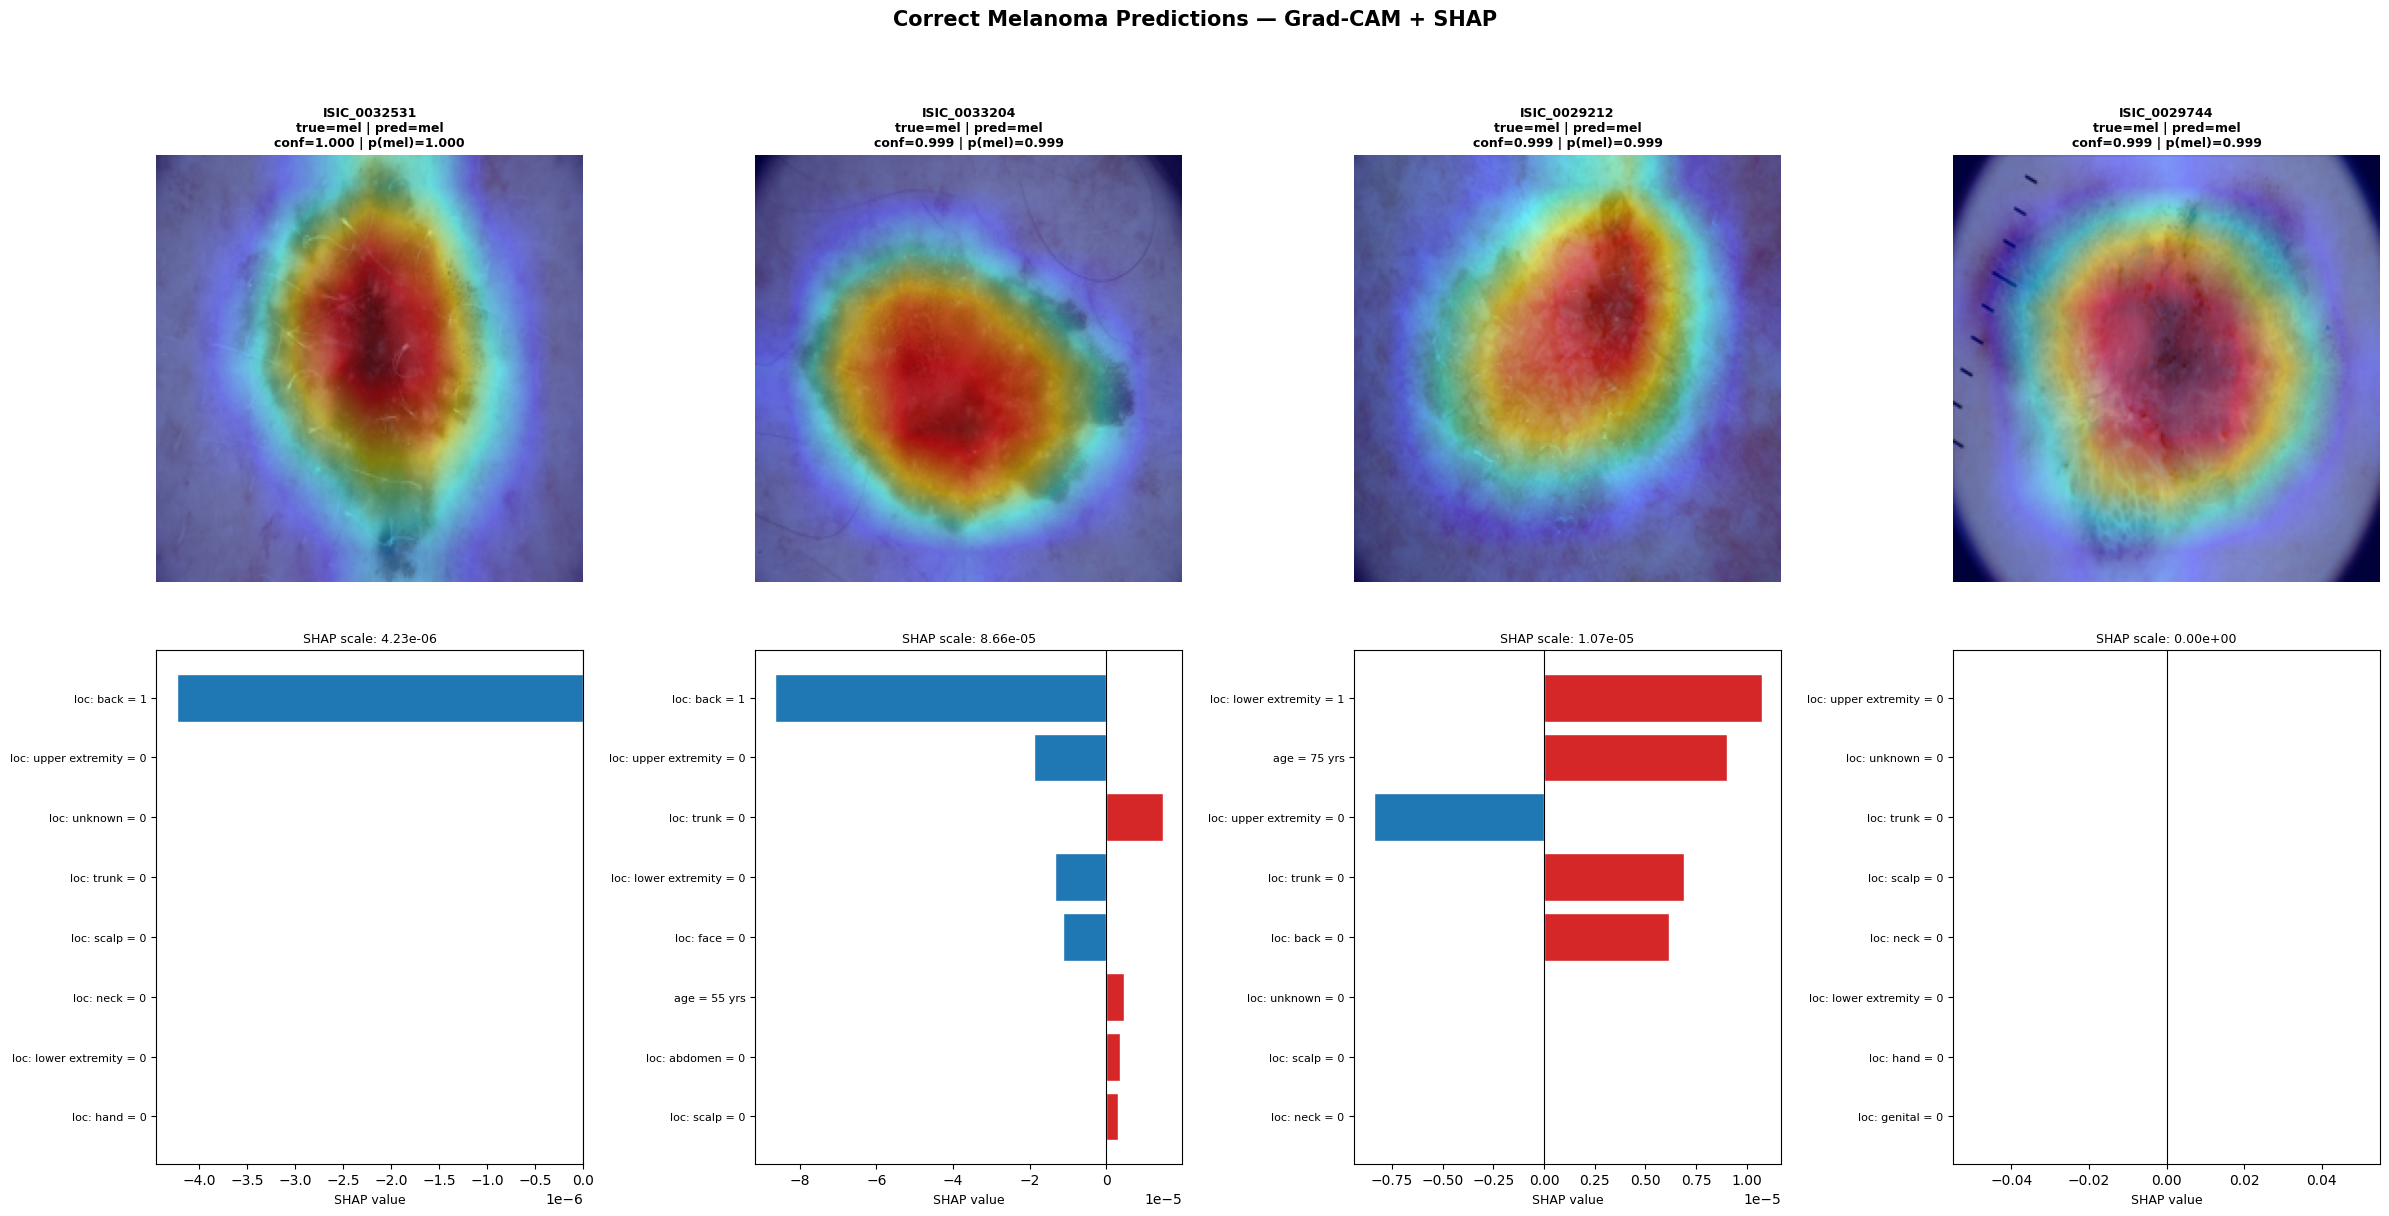

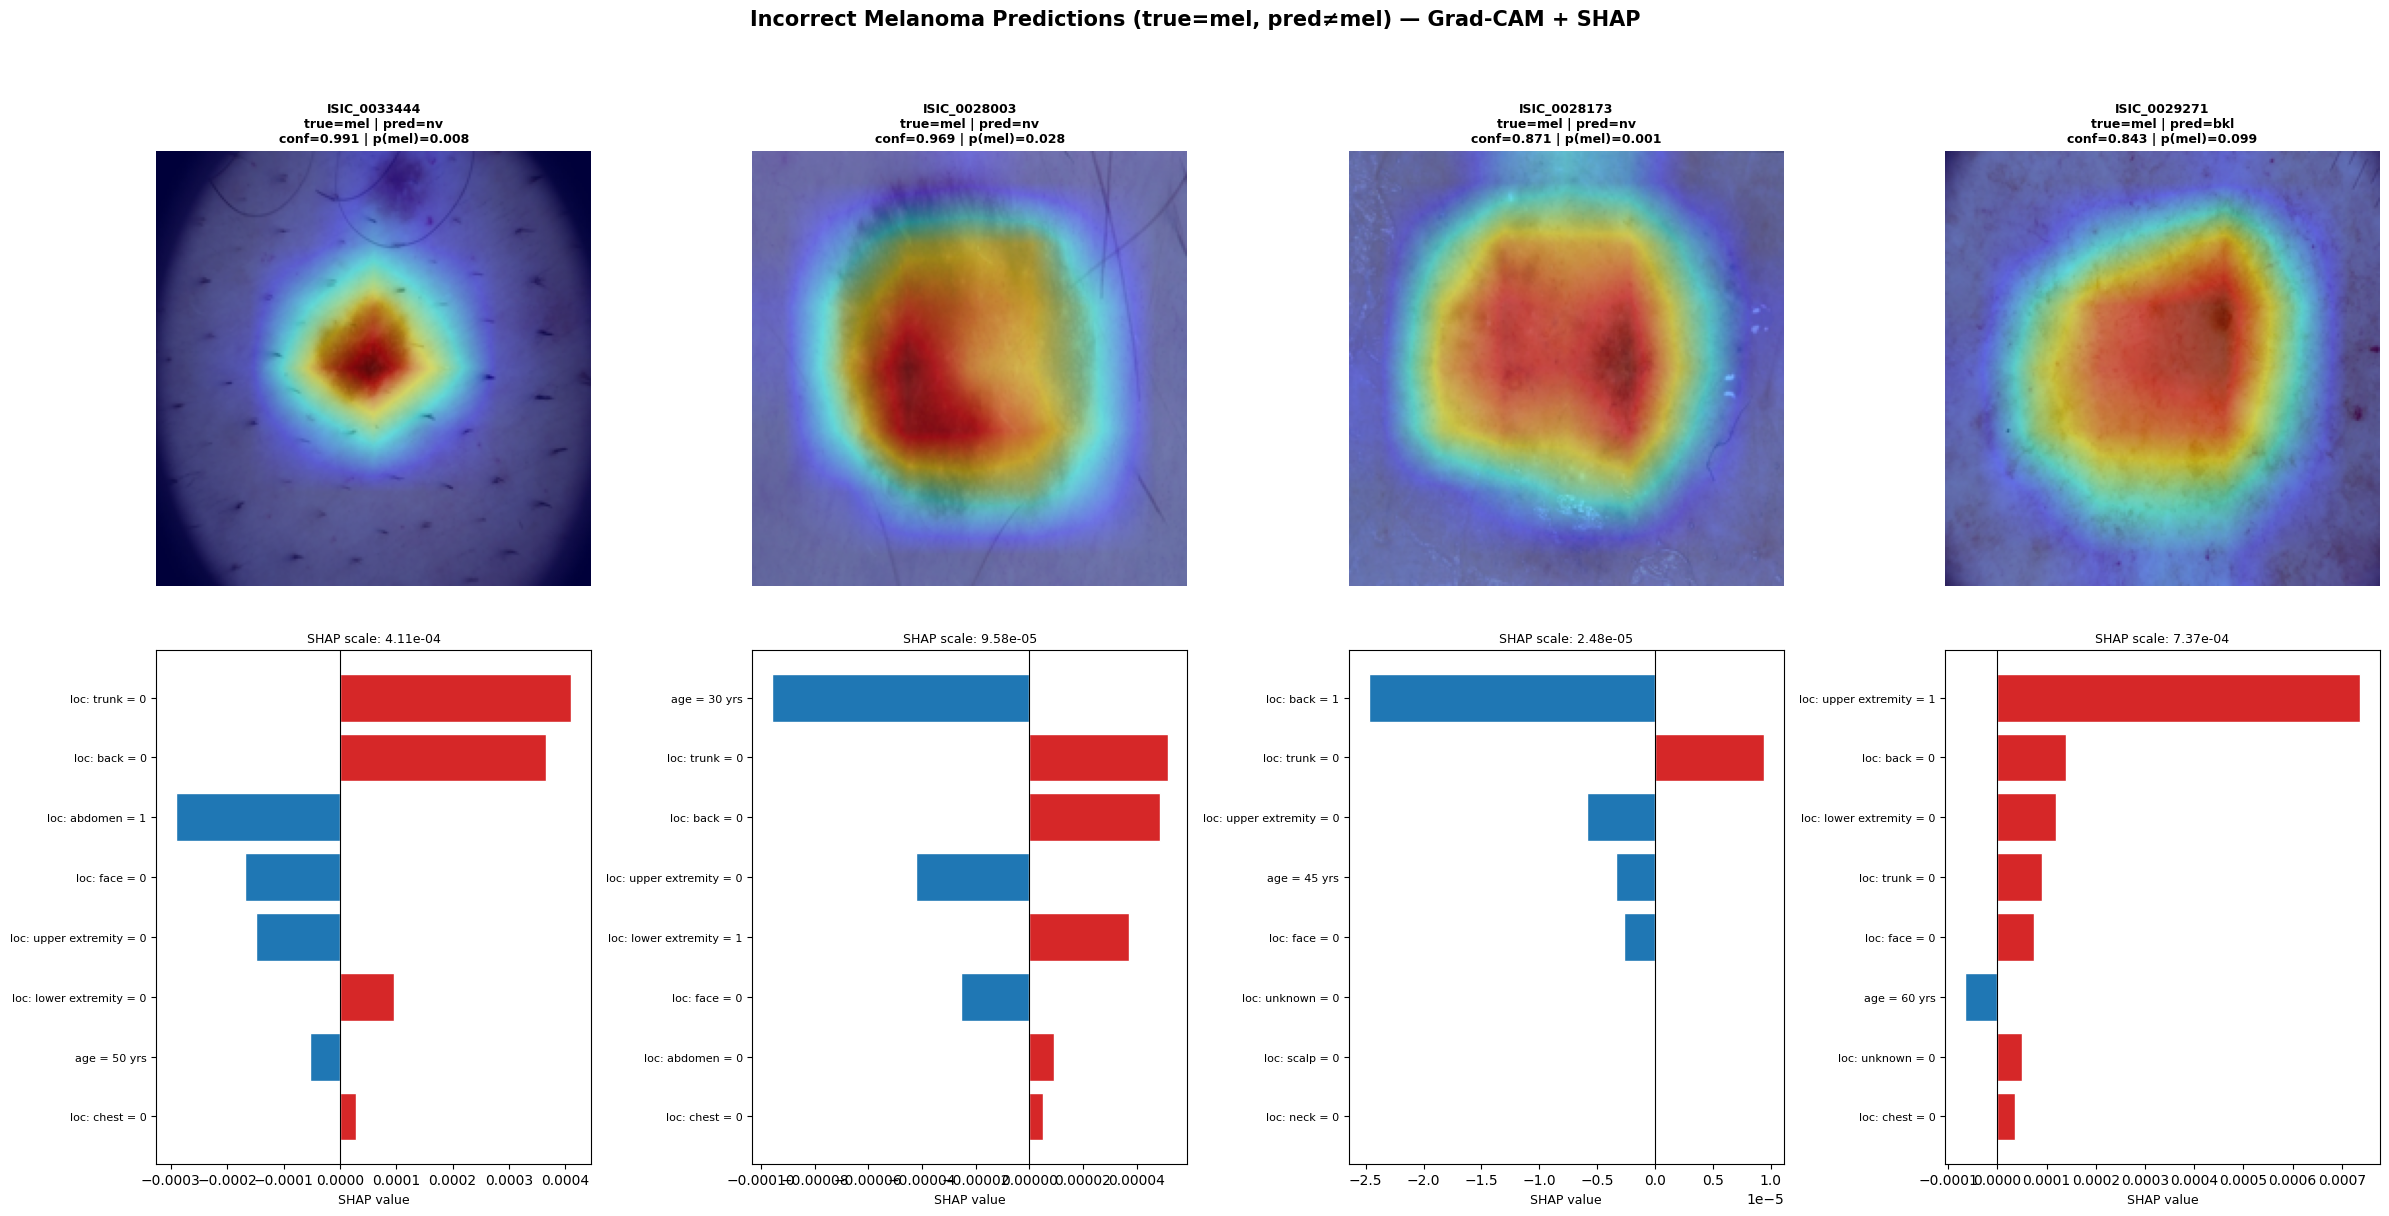

In [9]:
# Cell 13 — Plotting function for the comparison figures

def plot_comparison_figure(cases_results, group_label, save_path):
    """
    4-case comparison figure.
    Each case occupies 2 rows: Grad-CAM (top) + SHAP bar chart (bottom).
    Layout: 2 rows × 4 columns, with a divider between visual and SHAP rows.
    """
    n = len(cases_results)
    fig = plt.figure(figsize=(6 * n, 12))
    fig.suptitle(group_label, fontsize=15, fontweight="bold", y=1.01)

    for col, res in enumerate(cases_results):
        case        = res["case"]
        img_rgb     = res["img_rgb"]
        gradcam     = res["gradcam"]
        shap_values = res["shap_values"]
        meta_vector = res["meta_vector"]

        overlay = overlay_heatmap(img_rgb, gradcam)

        # --- Top row: Grad-CAM overlay ---
        ax_img = fig.add_subplot(2, n, col + 1)
        ax_img.imshow(overlay)
        ax_img.axis("off")
        ax_img.set_title(
            f"{case['image_id']}\n"
            f"true={case['true_class']} | pred={case['pred_class']}\n"
            f"conf={case['confidence']:.3f} | p(mel)={case['prob_mel']:.3f}",
            fontsize=9, fontweight="bold"
        )

        # --- Bottom row: SHAP bar chart (top 8 features) ---
        ax_shap = fig.add_subplot(2, n, n + col + 1)

        # Build labels
        labels = []
        for i, name in enumerate(METADATA_FEATURE_NAMES):
            val = meta_vector[i]
            if i == 0:
                labels.append(f"{name} = {val * 90:.0f} yrs")
            else:
                labels.append(f"{name} = {int(val)}")

        # Top 8 by absolute SHAP
        order         = np.argsort(np.abs(shap_values))[::-1][:8]
        sorted_shap   = shap_values[order]
        sorted_labels = [labels[i] for i in order]
        colors        = ["#d62728" if v > 0 else "#1f77b4" for v in sorted_shap]

        ax_shap.barh(range(len(sorted_shap)), sorted_shap, color=colors, edgecolor="white")
        ax_shap.set_yticks(range(len(sorted_labels)))
        ax_shap.set_yticklabels(sorted_labels, fontsize=8)
        ax_shap.axvline(0, color="black", linewidth=0.8)
        ax_shap.invert_yaxis()
        ax_shap.set_xlabel("SHAP value", fontsize=9)
        ax_shap.set_title(
            f"SHAP scale: {np.abs(shap_values).max():.2e}",
            fontsize=9
        )

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Figure saved: {save_path}")
    return fig

# --- Generate both figures ---
correct_results   = results[:4]
incorrect_results = results[4:]

fig_correct = plot_comparison_figure(
    correct_results,
    group_label="Correct Melanoma Predictions — Grad-CAM + SHAP",
    save_path=os.path.join(OUTPUT_DIR, "correct_melanomas_comparison.png"),
)

fig_incorrect = plot_comparison_figure(
    incorrect_results,
    group_label="Incorrect Melanoma Predictions (true=mel, pred≠mel) — Grad-CAM + SHAP",
    save_path=os.path.join(OUTPUT_DIR, "incorrect_melanomas_comparison.png"),
)

plt.show()

Correctos (figura 1):

- Los 4 Grad-CAM perfectamente centrados sobre la lesión — el modelo mira exactamente donde debe en todos los casos.
- SHAP casi todos azules (contra melanoma) o planos — aparentemente contradictorio, pero tiene sentido: las localizaciones ausentes (=0) como loc: back=0 en ISIC_0033204 empujan ligeramente contra melanoma porque el modelo sabe que el back es zona de alta prevalencia de melanoma y al no estar presente, resta un poco. Aun así las escalas son tan pequeñas (1e-6 a 1e-5) que son irrelevantes.
- ISIC_0029212 es el más interesante: loc: lower extremity=1 y age=75 con barras rojas — los metadatos empujan activamente hacia melanoma y el modelo acierta. Los metadatos ayudan.
- ISIC_0029744 → SHAP=0, decisión 100% imagen.

Incorrectos (figura 2):

- Los 4 Grad-CAM también bien centrados — confirma que el fallo no es visual.
- ISIC_0033444: loc: trunk=0 y loc: back=0 en rojo — la ausencia de zonas típicas de melanoma empuja contra melanoma. loc: abdomen=1 en azul — el abdomen actúa como señal de benignidad.
- ISIC_0028003: age=30 en azul enorme — edad joven empuja fuertemente contra melanoma. loc: trunk=0 y loc: back=0 en rojo — la ausencia de localizaciones típicas refuerza el fallo.
- ISIC_0028173: loc: back=1 en azul — el back debería ser pro-melanoma pero aquí empuja contra. Escala pequeña (2.48e-05), el fallo más débil del grupo.
- ISIC_0029271: loc: upper extremity=1 con la barra roja más grande de todas — pero espera, rojo significa pro-melanoma... sin embargo el modelo predice bkl. Esto es el caso más complejo — los metadatos dicen melanoma pero la imagen convence al modelo de que es bkl. Interesante inversión del patrón habitual.

## 6. Interpretation of Results

### 6.1 Visual localisation is correct in all cases

In all 8 cases — both correct and incorrect predictions — the Grad-CAM heatmap
is well-centred over the lesion, with intense activation at the nucleus. The model
never activates background skin or irrelevant regions. This confirms that **the
failure mode is not one of visual localisation but of feature interpretation**.
The model sees the lesion in every case. What differs is what it does with that
visual signal.

### 6.2 SHAP scale as the key discriminator

The most important quantitative finding of this notebook is the difference in
SHAP magnitude between the two groups:

| Group | SHAP scale (target = melanoma) |
|-------|-------------------------------|
| Correct predictions | 0.00e+00 – 8.66e-05 |
| Incorrect predictions | 2.48e-05 – 7.37e-04 |

The metadata branch contributes **10–100x more** in incorrect predictions than
in correct ones. When the image signal is unambiguous, metadata is irrelevant —
the model ignores it completely (ISIC_0029744: SHAP = 0.00). When the image is
borderline or the model is uncertain, the metadata branch intervenes at a
disproportionately large scale and can override the visual signal.

### 6.3 Case-by-case analysis

**Correct predictions:**
- The metadata contribution is negligible in 3 out of 4 cases. The image alone
  drives the prediction.
- **ISIC_0029212** is the exception: `loc: lower extremity = 1` and `age = 75 yrs`
  both push positively towards melanoma (red bars). In this case the metadata
  branch acts as a **clinical reinforcement** — the epidemiological signal
  (older patient, sun-exposed location) aligns with the visual signal and
  strengthens the correct prediction.

**Incorrect predictions:**
- **ISIC_0033444** (pred=nv): the absence of typical melanoma locations
  (`loc: trunk = 0`, `loc: back = 0`) pushes against melanoma, while
  `loc: abdomen = 1` acts as a benignity proxy. The model has learned that
  abdomen is a high-nv-prevalence zone in HAM10000 and applies that prior
  even when the image shows a melanoma.
- **ISIC_0028003** (pred=nv): `age = 30 yrs` is the dominant negative signal —
  young age pushes strongly against melanoma because melanoma is rare in young
  patients in the training data. This is a **dataset frequency bias**, not a
  clinical error per se, but it causes a dangerous misclassification.
- **ISIC_0028173** (pred=nv): `loc: back = 1` pushes against melanoma despite
  back being a high-melanoma-prevalence location overall. The SHAP scale is
  the smallest of the four incorrect cases (2.48e-05), suggesting this failure
  is closer to a pure visual misinterpretation than a metadata override.
- **ISIC_0029271** (pred=bkl): the most interesting case. `loc: upper extremity = 1`
  shows the largest red bar of all 8 cases — pushing strongly **towards** melanoma.
  Yet the model predicts bkl. This is an **inversion of the typical failure pattern**:
  the metadata correctly supports melanoma but the image branch convinces the model
  otherwise. The failure here is primarily visual, not metadata-driven.

### 6.4 The MetadataBranch as a double-edged mechanism

Taken together, these cases reveal that the MetadataBranch acts as a
**double-edged clinical mechanism**:

- When metadata aligns with the correct visual signal → it reinforces the
  prediction and improves confidence (ISIC_0029212).
- When metadata encodes dataset frequency biases (high nv prevalence at certain
  locations, low melanoma prevalence in young patients) → it overrides the visual
  signal and causes dangerous misclassifications.

The primary failure mode is **shortcut learning by anatomical location and age**:
the model uses the empirical frequency of classes in HAM10000 as a prior, and
that prior is strong enough to suppress a correct visual prediction in the most
resistant failure cases.

mirar si borrar el siguiente markdown

## 7. Conclusions

This notebook provides an integrated synthesis of the visual (Grad-CAM) and
metadata (SHAP) explainability analyses for the final model E09, combining
the findings from notebooks 08 and 09 into a single coherent narrative.

### 7.1 The model always localises correctly

In all 8 cases — both correct and incorrect predictions — the Grad-CAM heatmap
is well-centred over the lesion with intense activation at the nucleus. The model
never activates background skin or irrelevant regions. **The failure mode of this
system is not one of visual localisation but of feature interpretation.**

### 7.2 SHAP scale as the key discriminator

The most important quantitative finding of this notebook is the contrast in
SHAP magnitude between the two groups:

| Group | SHAP scale (target = melanoma) |
|-------|-------------------------------|
| Correct predictions (n=4) | 0.00e+00 – 8.66e-05 |
| Incorrect predictions (n=4) | 2.48e-05 – 7.37e-04 |

The metadata branch contributes **10–100x more** in incorrect predictions than
in correct ones. When the image signal is unambiguous, the model ignores metadata
completely (ISIC_0029744: SHAP = 0.00). When the image is borderline, the metadata
branch intervenes at a disproportionately large scale and can override the visual
signal entirely.

### 7.3 The MetadataBranch as a double-edged mechanism

The 8 cases reveal two qualitatively different roles of the MetadataBranch:

**As clinical reinforcement (correct cases):**
When metadata aligns with the visual signal — as in ISIC_0029212 where
`loc: lower extremity = 1` and `age = 75 yrs` both push towards melanoma —
the metadata branch strengthens the correct prediction. The epidemiological
signal (older patient, sun-exposed location) acts as a clinically valid
tiebreaker.

**As a source of failure (incorrect cases):**
When metadata encodes dataset frequency biases, it overrides the visual signal:
- ISIC_0033444: `loc: abdomen = 1` acts as a benignity proxy → pred = nv
- ISIC_0028003: `age = 30 yrs` pushes strongly against melanoma → pred = nv
- ISIC_0028173: `loc: back = 1` pushes against melanoma despite back being
  a high-melanoma-prevalence location → pred = nv
- ISIC_0029271: the most atypical case — `loc: upper extremity = 1` pushes
  towards melanoma but the image branch overrides it → pred = bkl. This is
  the only case where the failure is primarily visual, not metadata-driven.

### 7.4 Connection to the broader XAI findings

This notebook bridges the findings from notebooks 08 and 09:

- **Notebook 08** showed that Grad-CAM localises correctly even in failure cases,
  and that forced melanoma Grad-CAM diverges spatially in 2/3 critical error cases —
  the melanoma signal exists at the lesion periphery but is suppressed.
- **Notebook 09** showed that the primary failure mechanism is shortcut learning
  by anatomical location, that metadata intervention is negatively correlated with
  confidence (r = -0.268, p = 4.54e-04), and that high metadata intervention is
  associated with 35% worse calibration (BS = 0.1458 vs 0.1080).
- **This notebook** provides the integrated case-level evidence: the same cases
  that show high SHAP magnitude are the ones where Grad-CAM is correctly focused
  but the prediction is wrong — confirming that the visual and metadata analyses
  are two sides of the same failure mechanism.

### 7.5 Clinical implications

The system is most dangerous when two conditions coincide simultaneously:
1. The image is visually borderline — the lesion does not show unambiguous
   malignant features.
2. The anatomical location or patient age encodes a strong benignity prior
   in HAM10000 — lower extremity, abdomen, young age.

In these cases, the metadata branch intervenes at a disproportionate scale,
the model becomes miscalibrated, and the uncertainty flag (max confidence < 0.70)
may not trigger because the model is confidently wrong rather than uncertain.
These are the most clinically dangerous failure cases in the system and the
primary target for future improvements.